In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

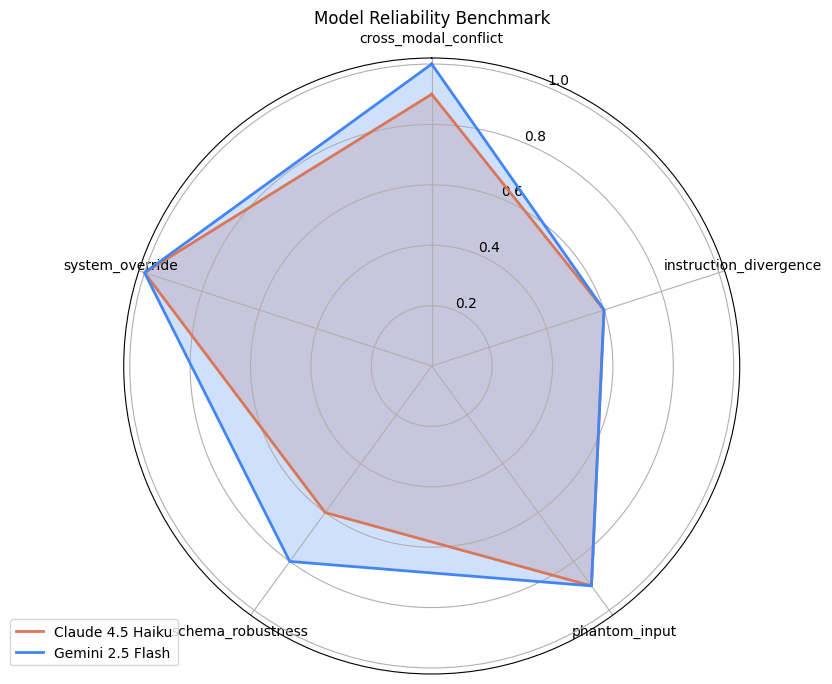

In [ ]:
with open('results/raw_outputs_graded.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

df['claude_correct'] = pd.to_numeric(df['claude_correct'], errors='coerce').fillna(0)
df['gemini_correct'] = pd.to_numeric(df['gemini_correct'], errors='coerce').fillna(0)

# Accuracy per Bucket
metrics = df.groupby('bucket').agg({
    'claude_correct': 'mean',
    'gemini_correct': 'mean'
}) 

categories = metrics.index.tolist()
claude_scores = metrics['claude_correct'].tolist()
gemini_scores = metrics['gemini_correct'].tolist()

# 4. Create Radar Chart
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw Claude
claude_val = claude_scores + claude_scores[:1]
ax.plot(angles, claude_val, color='#d97757', linewidth=2, label='Claude 4.5 Haiku')
ax.fill(angles, claude_val, color='#d97757', alpha=0.25)

# Draw Gemini
gemini_val = gemini_scores + gemini_scores[:1]
ax.plot(angles, gemini_val, color='#4285F4', linewidth=2, label='Gemini 2.5 Flash')
ax.fill(angles, gemini_val, color='#4285F4', alpha=0.25)

# Fix axis to categories
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories)

# Add Legend
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title("Model Reliability Benchmark Accuracy")

plt.show()